# K-means Colour Clustering Banana Ripeness Classification

This standalone assignment notebook implements the K-means colour clustering-based image-processing pipeline directly from the raw banana ripeness dataset.

**How to run:** install the imported packages, choose **Run All**, and enter the dataset root containing `train`, `valid` (or `validation`), and `test`. The notebook creates a timestamped local `results` folder. Test data is used only in the final evaluation.

## 1. Imports and frozen configuration

All project logic is defined in this notebook. The constants below are fixed and are not tuned after viewing test results.

In [2]:
%pip install numpy pandas matplotlib opencv-python scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from __future__ import annotations
%matplotlib inline

import random
import time
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Iterable, Sequence

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import silhouette_score

RANDOM_SEED = 42
EXPECTED_SIZE = (416, 416)
CLASS_ORDER = ["unripe", "ripe", "overripe", "rotten"]
SUBSETS = ("train", "valid", "test")
EXPECTED_COUNTS = {
    "train": 11793,
    "valid": 1123,
    "test": 562
}

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

MEDIAN_KERNEL = 3

K_VALUES = list(range(2, 9))
IMAGES_PER_CLASS = 10
PIXELS_PER_IMAGE = 2000
SILHOUETTE_SAMPLE_SIZE = 10000

K_CLUSTERS = 3

CLUSTER_FEATURES = []
for cluster_id in range(K_CLUSTERS):
    CLUSTER_FEATURES.extend([
        f"cluster_{cluster_id + 1}_L_star",
        f"cluster_{cluster_id + 1}_a_star",
        f"cluster_{cluster_id + 1}_b_star",
        f"cluster_{cluster_id + 1}_proportion"
    ])

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 2. Dataset path and output directory

Enter only the dataset root. No machine-specific previous output is required.

In [2]:
DATASET_DIR = Path(
    r"C:\Users\Lim Kai wei\Downloads\Banana Ripeness Classification Dataset"
)

if not DATASET_DIR.is_dir():
    raise FileNotFoundError(
        f"Dataset directory does not exist: {DATASET_DIR}"
    )

timestamp = datetime.now().astimezone().strftime(
    "%Y%m%d_%H%M%S_%z"
)

RESULTS_DIR = (
    Path.cwd()
    / "results"
    / timestamp
).resolve()

suffix = 1

while RESULTS_DIR.exists():
    RESULTS_DIR = RESULTS_DIR.with_name(
        f"{timestamp}_{suffix:02d}"
    )
    suffix += 1

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True)

print(f"Dataset: {DATASET_DIR}")
print(f"Outputs: {RESULTS_DIR}")

Dataset: C:\Users\Lim Kai wei\Downloads\Banana Ripeness Classification Dataset
Outputs: C:\Users\Lim Kai wei\Downloads\results\20260907_161119_+0800


## 3. Dataset loading and verification

The original train, validation, and test splits and fixed class order are validated before any image processing.

In [3]:
class DatasetError(RuntimeError):
    """Raised when the dataset structure or an image is invalid."""


@dataclass(frozen=True)
class ImageRecord:
    """One deterministic dataset image entry."""

    path: Path
    relative_path: Path
    subset: str
    class_name: str


def resolve_subset_directory(
    root: Path,
    subset: str
) -> Path:
    """Resolve a dataset subset, accepting common directory aliases."""

    aliases = {
        "train": (
            "train",
            "training"
        ),
        "valid": (
            "valid",
            "validation",
            "val"
        ),
        "test": (
            "test",
            "testing"
        )
    }

    matches = [
        root / name
        for name in aliases[subset]
        if (root / name).is_dir()
    ]

    if len(matches) != 1:
        raise DatasetError(
            f"Expected exactly one directory for "
            f"{subset}; found {matches}"
        )

    return matches[0]


def iter_image_records(
    root: Path,
    subsets: Sequence[str] = SUBSETS
) -> Iterable[ImageRecord]:
    """Yield images deterministically by subset, class, and relative path."""

    for subset in subsets:

        subset_dir = resolve_subset_directory(
            root,
            subset
        )

        actual_classes = sorted(
            path.name
            for path in subset_dir.iterdir()
            if path.is_dir()
        )

        if set(actual_classes) != set(CLASS_ORDER):
            raise DatasetError(
                f"{subset_dir} classes are "
                f"{actual_classes}; expected "
                f"{CLASS_ORDER}"
            )

        for class_name in CLASS_ORDER:

            class_dir = (
                subset_dir
                / class_name
            )

            paths = sorted(
                (
                    path
                    for path in class_dir.rglob("*")
                    if (
                        path.is_file()
                        and path.suffix.lower()
                        in IMAGE_EXTENSIONS
                    )
                ),
                key=lambda path:
                    path.relative_to(root)
                    .as_posix()
                    .lower()
            )

            for path in paths:

                yield ImageRecord(
                    path.resolve(),
                    path.relative_to(root),
                    subset,
                    class_name
                )


records = list(
    iter_image_records(
        DATASET_DIR
    )
)


manifest = pd.DataFrame(
    [
        {
            "image_path":
                record.relative_path.as_posix(),
            "subset":
                record.subset,
            "ground_truth_class":
                record.class_name
        }
        for record in records
    ]
)


if (
    manifest.empty
    or not manifest[
        "image_path"
    ].is_unique
):
    raise DatasetError(
        "The dataset manifest is empty "
        "or contains duplicate relative paths."
    )


dataset_counts = (
    manifest
    .groupby(
        [
            "subset",
            "ground_truth_class"
        ],
        observed=False
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        index=SUBSETS,
        columns=CLASS_ORDER
    )
)


dataset_counts["Total"] = (
    dataset_counts.sum(
        axis=1
    )
)


dataset_counts.loc["Total"] = (
    dataset_counts.sum(
        axis=0
    )
)


display(dataset_counts)


for subset, expected in EXPECTED_COUNTS.items():

    actual = int(
        (
            manifest["subset"]
            == subset
        ).sum()
    )

    if actual != expected:

        raise DatasetError(
            f"{subset} has "
            f"{actual} images; "
            f"expected {expected}"
        )


if len(records) != 13478:

    raise DatasetError(
        f"Found {len(records)} images; "
        f"expected 13,478"
    )


manifest.to_csv(
    RESULTS_DIR
    / "dataset_manifest.csv",
    index=False
)

print(
    "Dataset counts verified successfully."
)

ground_truth_class,unripe,ripe,overripe,rotten,Total
subset,,,,,
train,1902,3522,2349,4020,11793
valid,167,339,229,388,1123
test,110,154,113,185,562
Total,2179,4015,2691,4593,13478


Dataset counts verified successfully.


## 4. Common image preparation

Each file is decoded using OpenCV, converted from BGR to RGB, and standardised to a 416 × 416 three-channel image. Images with different dimensions are resized to the target resolution using area interpolation.

In [4]:
def load_and_prepare_rgb(record):
    try:
        encoded = np.fromfile(
            record.path,
            dtype=np.uint8
        )

        bgr = cv2.imdecode(
            encoded,
            cv2.IMREAD_COLOR
        )

    except Exception as exc:
        raise DatasetError(
            f"Could not read {record.path}: {exc}"
        ) from exc

    if bgr is None:
        raise DatasetError(
            f"OpenCV could not decode {record.path}"
        )

    # Convert the decoded OpenCV image from BGR to RGB colour order
    rgb = cv2.cvtColor(
        bgr,
        cv2.COLOR_BGR2RGB
    )

    # Standardise images with different dimensions to 416 × 416 pixels
    if rgb.shape[:2] != (
        EXPECTED_SIZE[1],
        EXPECTED_SIZE[0]
    ):
        rgb = cv2.resize(
            rgb,
            EXPECTED_SIZE,
            interpolation=cv2.INTER_AREA
        )

    expected_shape = (
        EXPECTED_SIZE[1],
        EXPECTED_SIZE[0],
        3
    )

    if (
        rgb.shape != expected_shape
        or rgb.dtype != np.uint8
    ):
        raise DatasetError(
            f"Unexpected prepared image: "
            f"{rgb.shape}, {rgb.dtype}: "
            f"{record.path}"
        )

    return rgb

In [5]:
def prepare_lab_image(
    rgb: np.ndarray
) -> np.ndarray:

    # Reduce isolated image noise while preserving important colour boundaries
    filtered_rgb = cv2.medianBlur(
        rgb,
        MEDIAN_KERNEL
    )

    filtered_float = (
        filtered_rgb.astype(np.float32)
        / 255.0
    )

    # Convert the filtered RGB image to the CIELAB colour space
    lab = cv2.cvtColor(
        filtered_float,
        cv2.COLOR_RGB2LAB
    )

    return lab

### Image preparation demonstration

The following example illustrates the effect of the 3 × 3 median filter used during image preparation. The median filter reduces isolated image noise while preserving important colour boundaries before conversion to the CIELAB colour space.

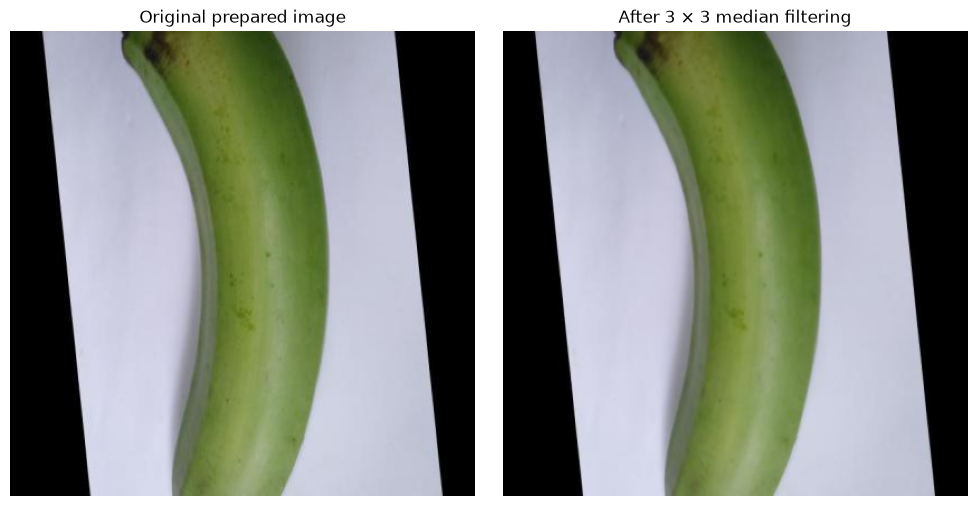

Saved: C:\Users\Lim Kai wei\Downloads\results\20260907_161119_+0800\figures\image_preparation_demonstration.png


In [6]:
sample_record = records[0]

sample_rgb = load_and_prepare_rgb(
    sample_record
)

sample_filtered_rgb = cv2.medianBlur(
    sample_rgb,
    MEDIAN_KERNEL
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

axes[0].imshow(
    sample_rgb
)
axes[0].set_title(
    "Original prepared image"
)
axes[0].axis(
    "off"
)

axes[1].imshow(
    sample_filtered_rgb
)
axes[1].set_title(
    "After 3 × 3 median filtering"
)
axes[1].axis(
    "off"
)

fig.tight_layout()

preparation_figure = (
    FIGURES_DIR
    / "image_preparation_demonstration.png"
)

fig.savefig(
    preparation_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    preparation_figure
)

### CIELAB colour-space representation

The median-filtered image is converted from RGB to the CIELAB colour space before K-means clustering. The `L*`, `a*`, and `b*` channels represent the lightness and colour information used as pixel-level features for clustering.

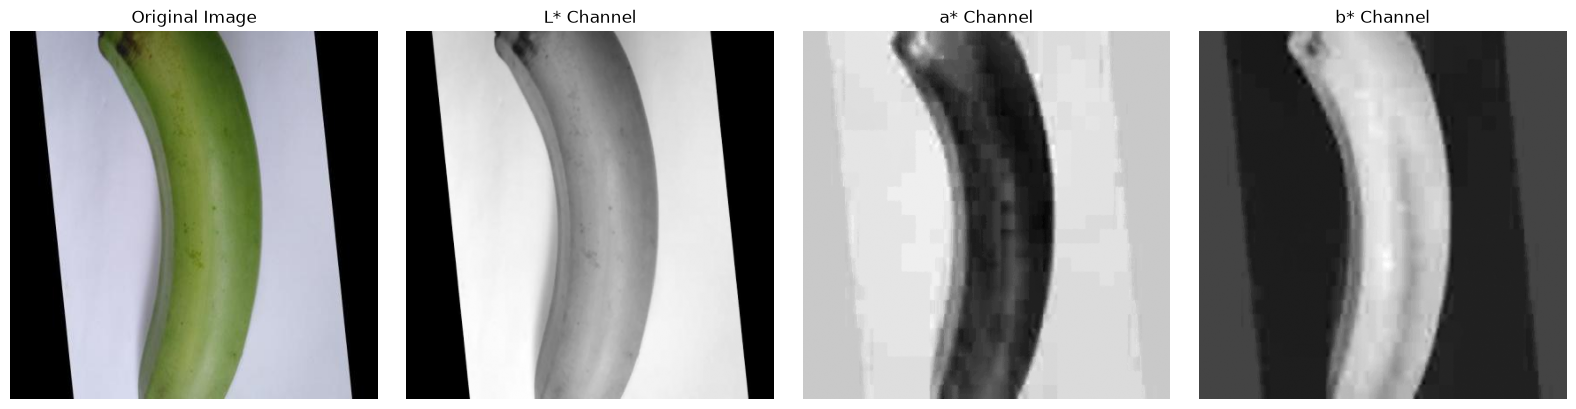

Saved: C:\Users\Lim Kai wei\Downloads\results\20260907_161119_+0800\figures\cielab_channels_demonstration.png


In [7]:
sample_lab = prepare_lab_image(
    sample_rgb
)

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

axes[0].imshow(sample_rgb)
axes[0].set_title("Original Image")

axes[1].imshow(
    sample_lab[:, :, 0],
    cmap="gray"
)
axes[1].set_title("L* Channel")

axes[2].imshow(
    sample_lab[:, :, 1],
    cmap="gray"
)
axes[2].set_title("a* Channel")

axes[3].imshow(
    sample_lab[:, :, 2],
    cmap="gray"
)
axes[3].set_title("b* Channel")

for ax in axes:
    ax.axis("off")

fig.tight_layout()

lab_figure = (
    FIGURES_DIR
    / "cielab_channels_demonstration.png"
)

fig.savefig(
    lab_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    lab_figure
)

## 5. Preliminary selection of K

A preliminary experiment was conducted to determine an appropriate number of colour clusters before the final K-means classification experiment. Only images from the training subset were used for this selection process, while the validation and test subsets remained unused.

Candidate values from K = 2 to K = 8 were evaluated using the Elbow Method, Silhouette Score, and visual comparison of the resulting cluster maps. A fixed random seed was used to ensure reproducibility.

In [10]:
# Select an equal number of training images from each class
selection_rng = random.Random(
    RANDOM_SEED
)

selected_records = {}

for class_name in CLASS_ORDER:
    class_records = [
        record
        for record in records
        if record.subset == "train"
        and record.class_name == class_name
    ]

    if len(class_records) < IMAGES_PER_CLASS:
        raise ValueError(
            f"Not enough training images for {class_name}"
        )

    selected_records[class_name] = selection_rng.sample(
        class_records,
        IMAGES_PER_CLASS
    )

    print(
        f"{class_name}: "
        f"{len(selected_records[class_name])} selected"
    )

total_selected = sum(
    len(class_records)
    for class_records in selected_records.values()
)

print(
    f"\nTotal selected training images: "
    f"{total_selected}"
)

unripe: 10 selected
ripe: 10 selected
overripe: 10 selected
rotten: 10 selected

Total selected training images: 40


In [11]:
# Sample CIELAB pixels from the selected training images
pixel_rng = np.random.default_rng(
    RANDOM_SEED
)

sampled_pixels = []

for class_name in CLASS_ORDER:
    for record in selected_records[class_name]:
        rgb = load_and_prepare_rgb(
            record
        )

        lab = prepare_lab_image(
            rgb
        )

        pixels = lab.reshape(
            -1,
            3
        ).astype(np.float32)

        indices = pixel_rng.choice(
            len(pixels),
            size=PIXELS_PER_IMAGE,
            replace=False
        )

        sampled_pixels.append(
            pixels[indices]
        )

selection_pixels = np.vstack(
    sampled_pixels
).astype(np.float32)

print(
    "Selection pixel matrix shape:",
    selection_pixels.shape
)

print(
    "Expected shape:",
    (
        len(CLASS_ORDER)
        * IMAGES_PER_CLASS
        * PIXELS_PER_IMAGE,
        3
    )
)

Selection pixel matrix shape: (80000, 3)
Expected shape: (80000, 3)


### Quantitative evaluation of candidate K values

Candidate values from K = 2 to K = 8 were evaluated using two quantitative criteria. The inertia, or within-cluster sum of squares, was recorded for the Elbow Method, while the Silhouette Score was used to measure cluster cohesion and separation. All evaluations were performed using the sampled CIELAB pixels from the training subset only.

In [12]:
# Evaluate candidate K values using inertia and Silhouette Score
k_selection_results = []

for k in K_VALUES:
    print(
        f"Evaluating K = {k}..."
    )

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_SEED,
        n_init=10
    )

    cluster_labels = model.fit_predict(
        selection_pixels
    )

    silhouette = silhouette_score(
        selection_pixels,
        cluster_labels,
        sample_size=SILHOUETTE_SAMPLE_SIZE,
        random_state=RANDOM_SEED
    )

    k_selection_results.append(
        {
            "K": k,
            "Inertia": model.inertia_,
            "Silhouette Score": silhouette
        }
    )

k_selection_frame = pd.DataFrame(
    k_selection_results
)

display(
    k_selection_frame
)

Evaluating K = 2...
Evaluating K = 3...
Evaluating K = 4...
Evaluating K = 5...
Evaluating K = 6...
Evaluating K = 7...
Evaluating K = 8...


,K,Inertia,Silhouette Score
0,2,50885888.0,0.495874
1,3,23026392.0,0.595693
2,4,18151364.0,0.542665
3,5,15332331.0,0.448027
4,6,13143120.0,0.423680
5,7,11271385.0,0.436885
6,8,9909513.0,0.444383


### Elbow Method and Silhouette Score

The Elbow Method and Silhouette Score were used together to identify an appropriate number of colour clusters. A suitable K value should provide a meaningful reduction in inertia while maintaining strong separation between the resulting clusters.

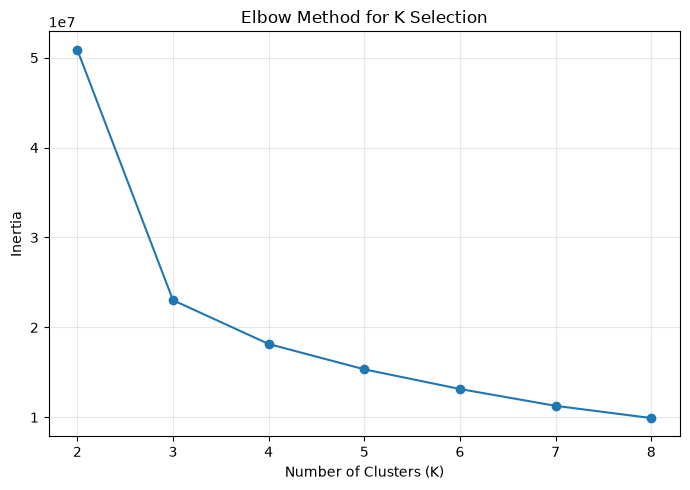

In [13]:
# Plot the Elbow Method results
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    k_selection_frame["K"],
    k_selection_frame["Inertia"],
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.title(
    "Elbow Method for K Selection"
)

plt.xticks(
    K_VALUES
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

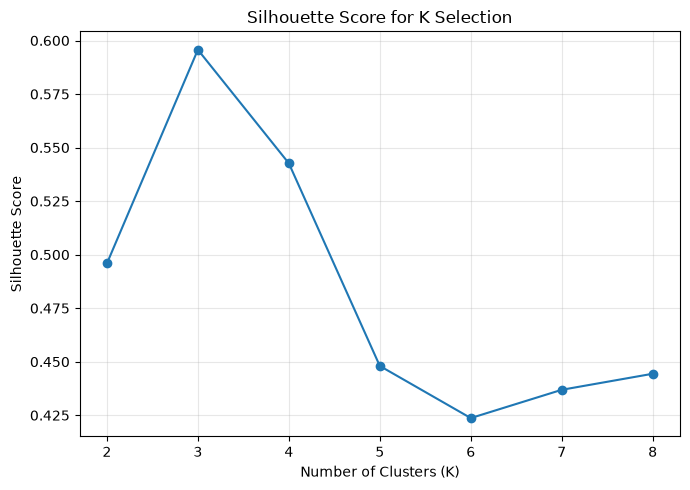

In [14]:
# Plot the Silhouette Score results
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    k_selection_frame["K"],
    k_selection_frame["Silhouette Score"],
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Silhouette Score for K Selection"
)

plt.xticks(
    K_VALUES
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

The Elbow Method indicated a clear reduction in the rate of improvement after K = 3, while K = 3 achieved the highest Silhouette Score among the evaluated candidates. Therefore, K = 3 was retained as the leading candidate for the final visual comparison.

### Visual comparison of candidate K values

In addition to the quantitative evaluation, one representative training image from each ripeness class was visually examined using K values from 2 to 8. This comparison was used to assess whether the resulting clusters provided meaningful colour-region separation without excessive fragmentation.

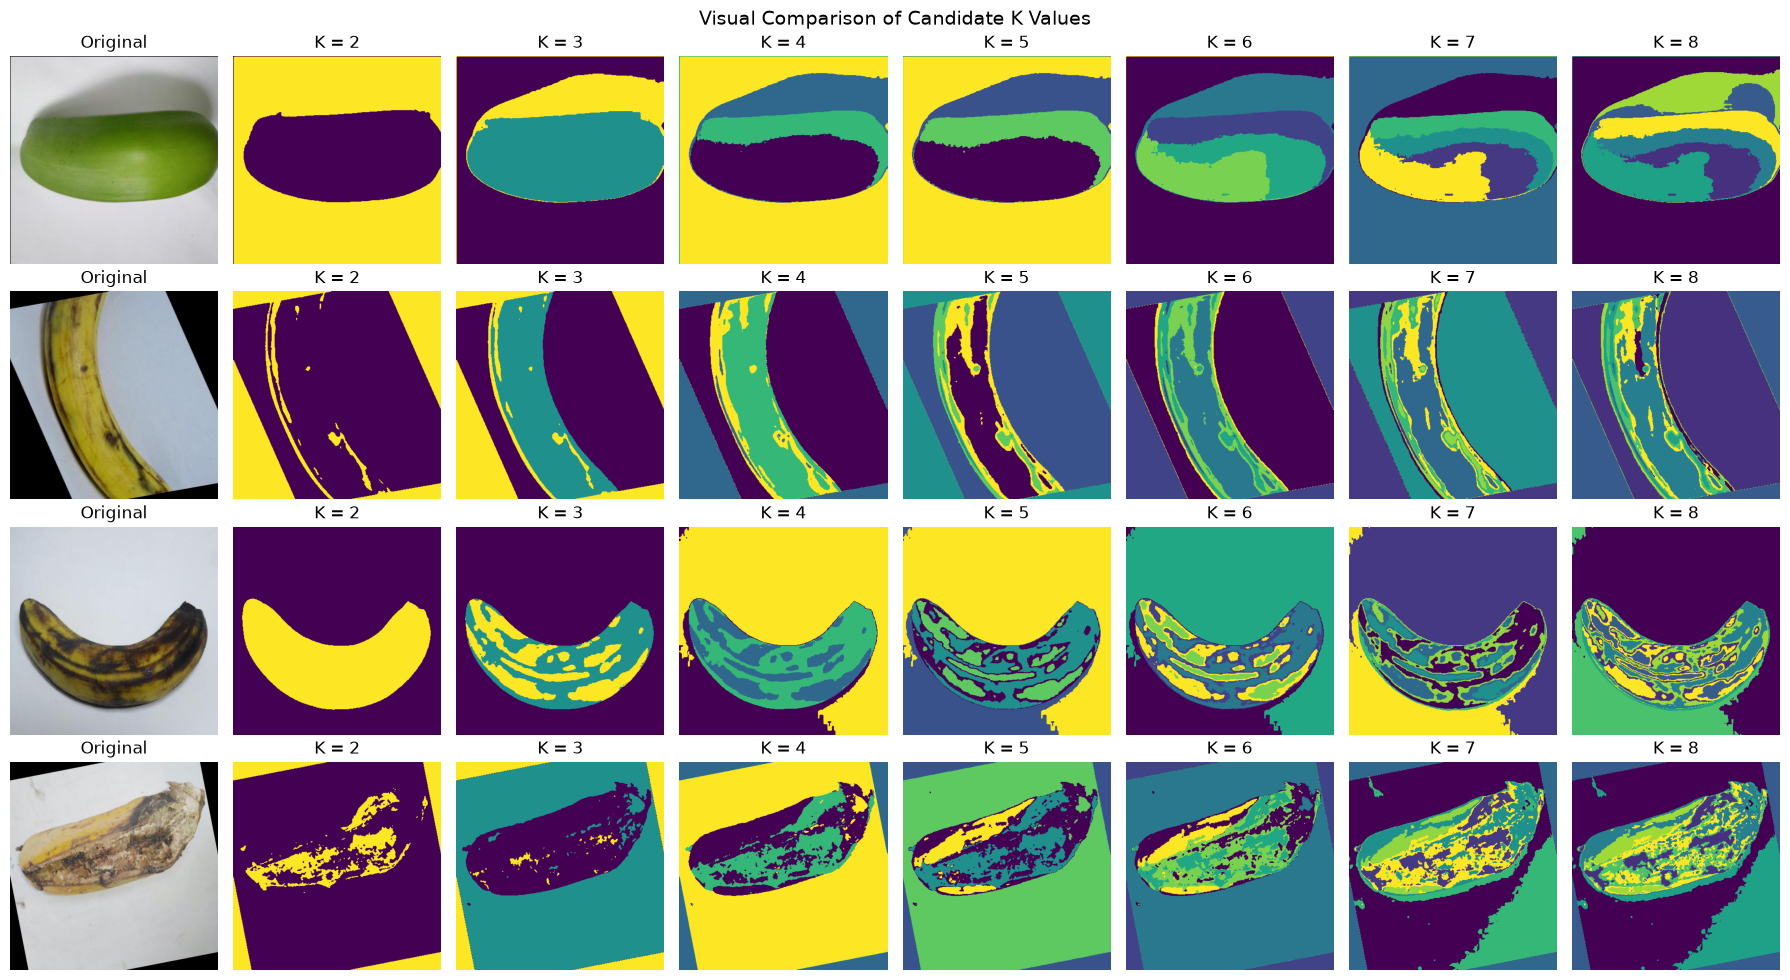

In [15]:
# Select one representative training image from each class
visual_records = {
    class_name: selected_records[class_name][0]
    for class_name in CLASS_ORDER
}

fig, axes = plt.subplots(
    len(CLASS_ORDER),
    len(K_VALUES) + 1,
    figsize=(18, 10)
)

for row, class_name in enumerate(CLASS_ORDER):
    record = visual_records[class_name]

    rgb = load_and_prepare_rgb(
        record
    )

    lab = prepare_lab_image(
        rgb
    )

    pixels = lab.reshape(
        -1,
        3
    ).astype(np.float32)

    axes[row, 0].imshow(
        rgb
    )

    axes[row, 0].set_ylabel(
        class_name.capitalize(),
        fontsize=11
    )

    axes[row, 0].set_title(
        "Original"
    )

    axes[row, 0].axis(
        "off"
    )

    for col, k in enumerate(
        K_VALUES,
        start=1
    ):
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_SEED,
            n_init=10
        )

        labels = model.fit_predict(
            pixels
        )

        cluster_map = labels.reshape(
            lab.shape[:2]
        )

        axes[row, col].imshow(
            cluster_map,
            cmap="viridis"
        )

        axes[row, col].set_title(
            f"K = {k}"
        )

        axes[row, col].axis(
            "off"
        )

plt.suptitle(
    "Visual Comparison of Candidate K Values",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Final K selection

The quantitative and visual evaluations jointly supported K = 3 as an appropriate number of colour clusters. K = 2 produced comparatively coarse colour-region separation, whereas larger K values increasingly divided the images into smaller and more fragmented regions. K = 3 provided a suitable balance between meaningful colour-region representation and clustering complexity.

Furthermore, K = 3 achieved the highest Silhouette Score among the evaluated candidates and was consistent with the elbow observed in the inertia results. Therefore, K = 3 was selected and frozen for the final K-means colour clustering pipeline.

## 6. K-means colour clustering and feature extraction

Median filtering is first applied to reduce isolated image noise while preserving important colour boundaries. The filtered RGB image is then converted to CIELAB colour space. K-means clustering partitions the image pixels into a fixed number of colour clusters according to their CIELAB values.

The value `K = 3` as selected in the training-only preliminary experiment presented in Section 5 using the Elbow Method, Silhouette Score, and visual comparison before the final classification experiment was conducted.

For each cluster, the centroid colour (`L*`, `a*`, `b*`) and its pixel proportion are extracted. Because K-means cluster labels are arbitrary between images, the clusters are consistently ordered before the final fixed-length feature vector is constructed.

In [8]:
def extract_kmeans_features(
    rgb: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    lab = prepare_lab_image(rgb)

    # Reshape the image into pixel-level L*, a*, and b* features
    pixels = lab.reshape(
        -1,
        3
    ).astype(np.float32)

    # Partition all image pixels into the selected three colour clusters
    kmeans = KMeans(
        n_clusters=K_CLUSTERS,
        random_state=RANDOM_SEED,
        n_init=10
    )

    labels = kmeans.fit_predict(
        pixels
    )

    centroids = (
        kmeans.cluster_centers_
        .astype(np.float32)
    )

    counts = np.bincount(
        labels,
        minlength=K_CLUSTERS
    )

    # Calculate the proportion of image pixels assigned to each cluster
    proportions = (
        counts.astype(np.float32)
        / counts.sum()
    )

    cluster_features = np.column_stack(
        [
            centroids,
            proportions
        ]
    )

    # Order arbitrary K-means labels consistently by b*, followed by a* and L*
    order = np.lexsort(
        (
            cluster_features[:, 0],
            cluster_features[:, 1],
            cluster_features[:, 2]
        )
    )

    ordered_features = (
        cluster_features[order]
    )

    # Flatten the three ordered cluster descriptors into 12 features
    feature_vector = (
        ordered_features
        .reshape(-1)
        .astype(np.float32)
    )

    ordered_labels = np.empty_like(
        labels
    )

    for new_id, old_id in enumerate(order):
        ordered_labels[
            labels == old_id
        ] = new_id

    cluster_map = ordered_labels.reshape(
        lab.shape[:2]
    )

    return (
        feature_vector,
        cluster_map,
        ordered_features
    )

### Example cluster-based feature extraction

A sample image is processed using the frozen K-means pipeline to verify the extracted feature structure. For each of the three ordered clusters, the L*, a*, and b* centroid values and pixel proportion are retained, producing a 12-dimensional feature vector.

In [9]:
sample_record = records[0]

sample_rgb = load_and_prepare_rgb(
    sample_record
)

print(
    f"Sample image: {sample_record.path}"
)

print(
    f"Prepared RGB shape: {sample_rgb.shape}"
)

print(
    f"Prepared RGB dtype: {sample_rgb.dtype}"
)

Sample image: C:\Users\Lim Kai wei\Downloads\Banana Ripeness Classification Dataset\train\unripe\musa-acuminata-freshunripe-18f6ed60-2653-11ec-9fad-d8c4975e38aa_jpg.rf.9dadf252e09d3d155c1f0a035e6fb323.jpg
Prepared RGB shape: (416, 416, 3)
Prepared RGB dtype: uint8


In [10]:
sample_feature_vector, (
    sample_cluster_map
), sample_cluster_features = (
    extract_kmeans_features(
        sample_rgb
    )
)

print(
    "Feature vector shape:",
    sample_feature_vector.shape
)

print(
    "\nOrdered cluster features:"
)

sample_cluster_table = pd.DataFrame(
    sample_cluster_features,
    columns=[
        "L_star",
        "a_star",
        "b_star",
        "proportion"
    ]
)

display(sample_cluster_table)

print(
    "\nProportion sum:",
    sample_cluster_table[
        "proportion"
    ].sum()
)

Feature vector shape: (12,)

Ordered cluster features:


,L_star,a_star,b_star,proportion
0,79.289291,2.894806,-9.091608,0.471131
1,0.474884,0.012745,-0.003788,0.245839
2,49.410683,-17.310726,30.619946,0.283030



Proportion sum: 1.0


### K-means clustering demonstration

One representative training image from each ripeness class is displayed together with its K-means cluster map to demonstrate the colour regions produced by the frozen clustering pipeline.

The colours displayed in each cluster map represent cluster labels for visualisation purposes only and do not correspond to the original colours of the banana.

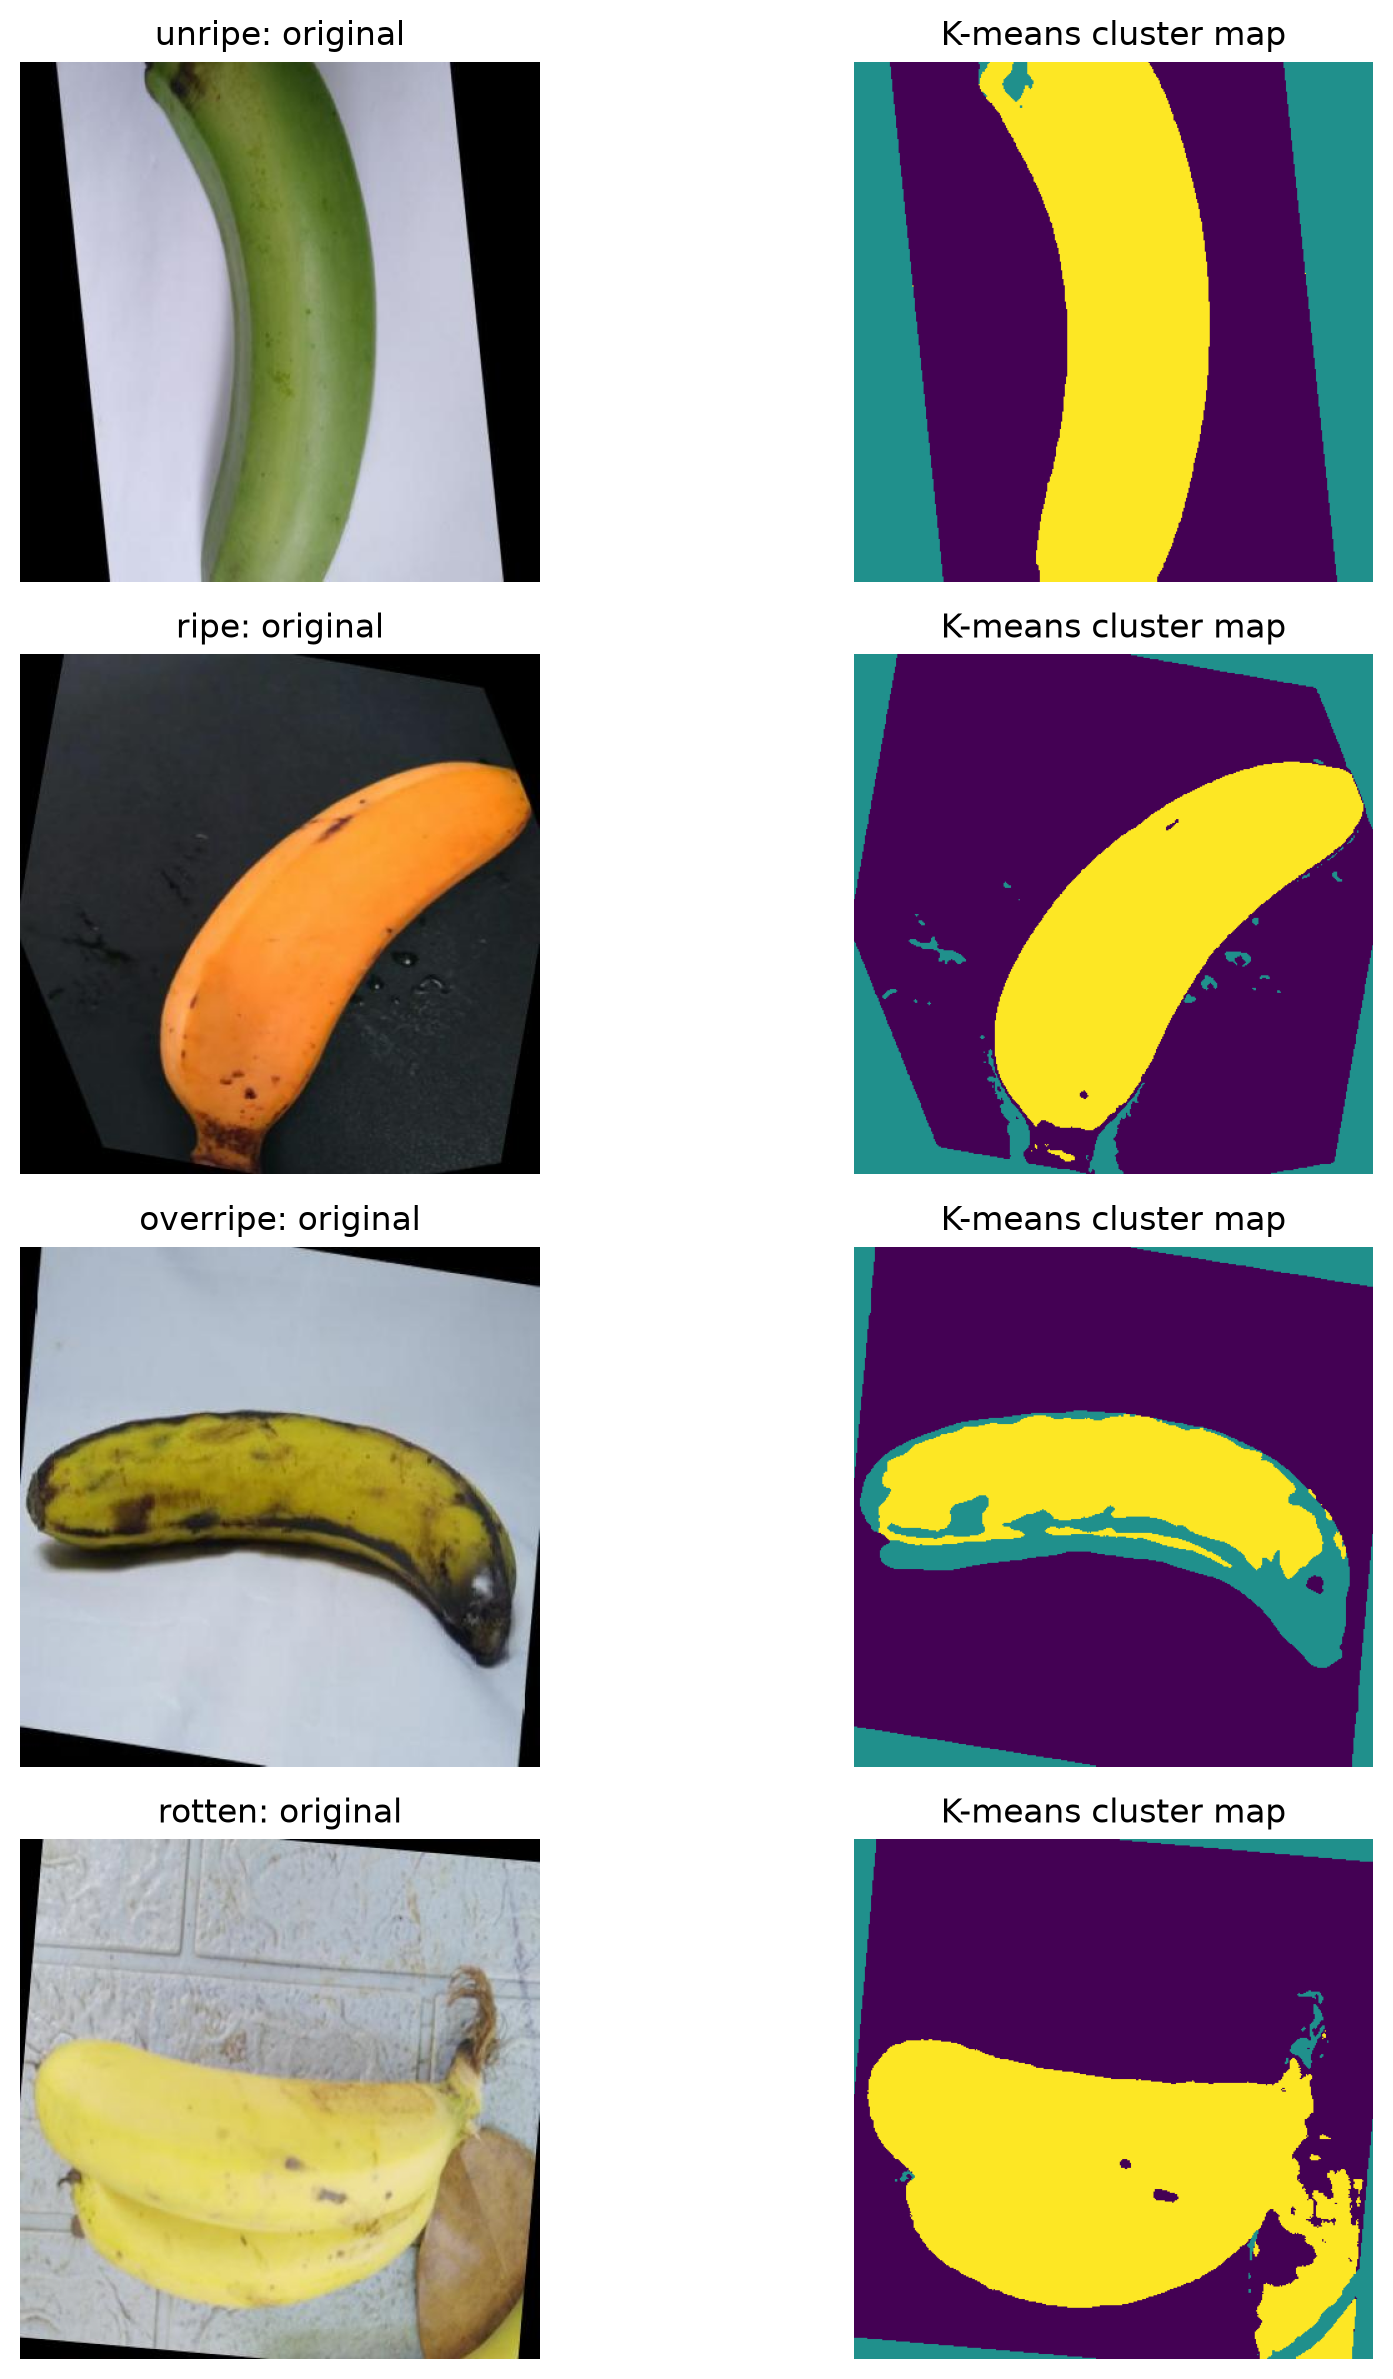

In [11]:
demonstration = [
    next(
        record
        for record in records
        if record.subset == "train"
        and record.class_name == name
    )
    for name in CLASS_ORDER
]

fig, axes = plt.subplots(
    len(CLASS_ORDER),
    2,
    figsize=(10, 12)
)

for row, record in enumerate(demonstration):

    rgb = load_and_prepare_rgb(record)

    _, cluster_map, _ = extract_kmeans_features(rgb)

    for column, (image_data, title, cmap) in enumerate((
        (
            rgb,
            f"{record.class_name}: original",
            None
        ),
        (
            cluster_map,
            "K-means cluster map",
            "viridis"
        )
    )):

        axes[row, column].imshow(
            image_data,
            cmap=cmap
        )

        axes[row, column].set_title(
            title
        )

        axes[row, column].axis(
            "off"
        )

fig.tight_layout()

clustering_figure = (
    FIGURES_DIR
    / "kmeans_clustering_demonstration.png"
)

fig.savefig(
    clustering_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

display(
    Image(
        filename=str(
            clustering_figure
        )
    )
)

## 7. Process all 13,478 raw images

The frozen K-means colour clustering pipeline is applied to every image in the original training, validation, and test subsets. Progress is printed after each 1,000 images and on the final image. Any processing failures are retained in a separate report.

In [12]:
# Measure feature-extraction time separately for each image
@dataclass(frozen=True)
class FeatureOutcome:
    feature_row: dict[str, object] | None
    failure_row: dict[str, object] | None


def extract_image_features(
    record: ImageRecord
) -> FeatureOutcome:

    started = time.perf_counter()

    base = {
        "image_path":
            record.relative_path.as_posix(),
        "subset":
            record.subset,
        "ground_truth_class":
            record.class_name
    }

    try:
        rgb = load_and_prepare_rgb(record)

        feature_vector, _, _ = (
            extract_kmeans_features(rgb)
        )

        elapsed = (
            time.perf_counter()
            - started
        )

        row = {
            **base,
            **{
                feature_name: float(value)
                for feature_name, value
                in zip(
                    CLUSTER_FEATURES,
                    feature_vector
                )
            },
            "processing_time_seconds":
                elapsed
        }

        return FeatureOutcome(
            row,
            None
        )

    except Exception as exc:

        elapsed = (
            time.perf_counter()
            - started
        )

        return FeatureOutcome(
            None,
            {
                **base,
                "failure_type":
                    type(exc).__name__,
                "failure_message":
                    str(exc),
                "processing_time_seconds":
                    elapsed
            }
        )

In [21]:
feature_rows = []
failure_rows = []

processing_started = (
    time.perf_counter()
)

total_images = len(records)

# Apply the frozen K-means feature extractor to every dataset image
for index, record in enumerate(
    records,
    start=1
):

    outcome = extract_image_features(
        record
    )

    if outcome.feature_row is not None:
        feature_rows.append(
            outcome.feature_row
        )
    else:
        failure_rows.append(
            outcome.failure_row
        )

    if (
        index % 1000 == 0
        or index == total_images
    ):
        elapsed = (
            time.perf_counter()
            - processing_started
        )

        print(
            f"[features] "
            f"{index:,}/{total_images:,} "
            f"processed; "
            f"failures={len(failure_rows)}; "
            f"elapsed={elapsed:.1f}s"
        )


total_processing_time = (
    time.perf_counter()
    - processing_started
)

all_features = pd.DataFrame(
    feature_rows
)

failures = pd.DataFrame(
    failure_rows,
    columns=[
        "image_path",
        "subset",
        "ground_truth_class",
        "failure_type",
        "failure_message",
        "processing_time_seconds"
    ]
)

all_features.to_csv(
    RESULTS_DIR
    / "kmeans_cluster_features.csv",
    index=False
)

failures.to_csv(
    RESULTS_DIR
    / "missing_or_invalid_features.csv",
    index=False
)

print(
    f"Total feature-processing time: "
    f"{total_processing_time:.1f}s"
)

[features] 1,000/13,478 processed; failures=0; elapsed=272.0s
[features] 2,000/13,478 processed; failures=0; elapsed=545.9s
[features] 3,000/13,478 processed; failures=0; elapsed=813.6s
[features] 4,000/13,478 processed; failures=0; elapsed=1080.5s
[features] 5,000/13,478 processed; failures=0; elapsed=1342.7s
[features] 6,000/13,478 processed; failures=0; elapsed=1644.5s
[features] 7,000/13,478 processed; failures=0; elapsed=1914.6s
[features] 8,000/13,478 processed; failures=0; elapsed=2194.8s
[features] 9,000/13,478 processed; failures=0; elapsed=2480.1s
[features] 10,000/13,478 processed; failures=0; elapsed=2749.9s
[features] 11,000/13,478 processed; failures=0; elapsed=3025.0s
[features] 12,000/13,478 processed; failures=0; elapsed=3303.0s
[features] 13,000/13,478 processed; failures=0; elapsed=3576.9s
[features] 13,478/13,478 processed; failures=0; elapsed=3708.9s
Total feature-processing time: 3708.9s


## 8. Complete K-means feature matrices

The extracted K-means features are separated according to the original training, validation, and test subsets. Each image is represented by 12 features derived from three consistently ordered colour clusters.

In [22]:
subset_features = {}

for subset in SUBSETS:

    frame = all_features.loc[
        all_features["subset"] == subset
    ].reset_index(drop=True)

    subset_features[subset] = frame

    frame.to_csv(
        RESULTS_DIR / f"{subset}_kmeans_features.csv",
        index=False
    )


feature_shapes = pd.DataFrame(
    [
        {
            "Subset": subset,
            "Number of images":
                len(subset_features[subset]),
            "Number of features":
                len(CLUSTER_FEATURES)
        }
        for subset in SUBSETS
    ]
)


processing_summary = pd.DataFrame(
    [
        {
            "Subset": subset,

            "Images processed":
                int(
                    (
                        manifest["subset"]
                        == subset
                    ).sum()
                ),

            "Failures":
                int(
                    (
                        failures["subset"]
                        == subset
                    ).sum()
                )
                if not failures.empty
                else 0,

            "Mean processing time":
                float(
                    subset_features[
                        subset
                    ][
                        "processing_time_seconds"
                    ].mean()
                )
        }
        for subset in SUBSETS
    ]
)


display(feature_shapes)

display(processing_summary)


feature_shapes.to_csv(
    RESULTS_DIR / "feature_matrix_shapes.csv",
    index=False
)

processing_summary.to_csv(
    RESULTS_DIR / "processing_summary.csv",
    index=False
)

,Subset,Number of images,Number of features
0,train,11793,12
1,valid,1123,12
2,test,562,12


,Subset,Images processed,Failures,Mean processing time
0,train,11793,0,0.274943
1,valid,1123,0,0.276927
2,test,562,0,0.276128


### Reload saved K-means features

In [16]:
from pathlib import Path

SAVED_FEATURE_FILE = Path(
    r"C:\Users\Lim Kai wei\Downloads\results\20260906_005900_+0800\kmeans_cluster_features.csv"
)

print(SAVED_FEATURE_FILE.exists())

True


In [17]:
import pandas as pd

all_features = pd.read_csv(
    SAVED_FEATURE_FILE
)

print(all_features.shape)
print(all_features.head())

(13478, 16)
                                          image_path subset  \
0  train/unripe/musa-acuminata-freshunripe-18f6ed...  train   
1  train/unripe/musa-acuminata-freshunripe-18f6ed...  train   
2  train/unripe/musa-acuminata-freshunripe-18f6ed...  train   
3  train/unripe/musa-acuminata-freshunripe-194473...  train   
4  train/unripe/musa-acuminata-freshunripe-194473...  train   

  ground_truth_class  cluster_1_L_star  cluster_1_a_star  cluster_1_b_star  \
0             unripe         79.289284          2.894806         -9.091610   
1             unripe         81.025955          4.872258        -11.841560   
2             unripe         81.641479          4.103124         -9.832464   
3             unripe         90.890442          2.298338         -5.673357   
4             unripe         81.847130          2.292344         -7.998898   

   cluster_1_proportion  cluster_2_L_star  cluster_2_a_star  cluster_2_b_star  \
0              0.471131          0.474884          0.012745

In [21]:
subset_features = {
    "train": all_features[
        all_features["subset"] == "train"
    ].copy(),

    "valid": all_features[
        all_features["subset"] == "valid"
    ].copy(),

    "test": all_features[
        all_features["subset"] == "test"
    ].copy()
}

print(
    "Train:",
    len(subset_features["train"])
)

print(
    "Valid:",
    len(subset_features["valid"])
)

print(
    "Test:",
    len(subset_features["test"])
)

Train: 11793
Valid: 1123
Test: 562


## 9. StandardScaler and default SVC

The agreed baseline classifier is exactly `StandardScaler()` followed by default `SVC()`. No classifier hyperparameters are tuned.

In [19]:
def make_model() -> Pipeline:

    # Apply feature standardisation before classification using the default SVC
    return Pipeline(
        [
            (
                "scaler",
                StandardScaler()
            ),
            (
                "svm",
                SVC()
            )
        ]
    )


def metric_tables(
    y_true: Sequence[str],
    y_pred: Sequence[str]
) -> tuple[
    pd.DataFrame,
    pd.DataFrame
]:

    macro = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=CLASS_ORDER,
            average="macro",
            zero_division=0
        )
    )

    weighted = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=CLASS_ORDER,
            average="weighted",
            zero_division=0
        )
    )

    aggregate = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Macro precision",
                "Macro recall",
                "Macro F1-score",
                "Weighted precision",
                "Weighted recall",
                "Weighted F1-score"
            ],

            "Value": [
                accuracy_score(
                    y_true,
                    y_pred
                ),
                macro[0],
                macro[1],
                macro[2],
                weighted[0],
                weighted[1],
                weighted[2]
            ]
        }
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0
    )

    per_class = pd.DataFrame(
        [
            {
                "Class": name,
                "Precision":
                    report[name][
                        "precision"
                    ],
                "Recall":
                    report[name][
                        "recall"
                    ],
                "F1-score":
                    report[name][
                        "f1-score"
                    ],
                "Support":
                    int(
                        report[name][
                            "support"
                        ]
                    )
            }
            for name in CLASS_ORDER
        ]
    )

    return (
        aggregate,
        per_class
    )

## 10. Validation experiment

The scaler and SVM are fitted on training features only, then evaluated on validation features. The test subset remains untouched during this stage.

In [22]:
train_frame = subset_features["train"]
valid_frame = subset_features["valid"]
test_frame = subset_features["test"]


for name, frame in subset_features.items():

    if (
        frame[CLUSTER_FEATURES]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .isna()
        .any()
        .any()
    ):
        raise ValueError(
            f"{name} contains invalid K-means feature values"
        )


validation_model = make_model()

# Fit the model using training data only
validation_model.fit(
    train_frame[CLUSTER_FEATURES],
    train_frame["ground_truth_class"]
)


# Evaluate the train-only fitted model on the training subset
training_prediction = validation_model.predict(
    train_frame[CLUSTER_FEATURES]
)

training_metrics, training_per_class = metric_tables(
    train_frame["ground_truth_class"],
    training_prediction
)

print("Training metrics")

display(
    training_metrics
)

training_metrics.to_csv(
    RESULTS_DIR / "training_metrics.csv",
    index=False
)


# Evaluate the same train-only fitted model on the validation subset
validation_prediction = validation_model.predict(
    valid_frame[CLUSTER_FEATURES]
)

validation_metrics, validation_per_class = metric_tables(
    valid_frame["ground_truth_class"],
    validation_prediction
)

print("Validation metrics")

display(
    validation_metrics
)

validation_metrics.to_csv(
    RESULTS_DIR / "validation_metrics.csv",
    index=False
)


validation_predictions = pd.DataFrame(
    {
        "image_path":
            valid_frame["image_path"],

        "true_class":
            valid_frame["ground_truth_class"],

        "predicted_class":
            validation_prediction,

        "processing_time_seconds":
            valid_frame["processing_time_seconds"]
    }
)

validation_predictions["correct"] = (
    validation_predictions["true_class"]
    == validation_predictions["predicted_class"]
)

validation_predictions.to_csv(
    RESULTS_DIR / "validation_predictions.csv",
    index=False
)

Training metrics


,Metric,Value
0,Accuracy,0.939371
1,Macro precision,0.941329
2,Macro recall,0.941913
3,Macro F1-score,0.941503
4,Weighted precision,0.939438
5,Weighted recall,0.939371
6,Weighted F1-score,0.939269


Validation metrics


,Metric,Value
0,Accuracy,0.945681
1,Macro precision,0.947195
2,Macro recall,0.952985
3,Macro F1-score,0.949827
4,Weighted precision,0.945917
5,Weighted recall,0.945681
6,Weighted F1-score,0.945554


## 11. Final test evaluation

**Final evaluation:** the classifier is fitted once on the combined training and validation K-means features, then used to predict the untouched 562-image test subset once.

In [23]:
# Combine training and validation features only after model selection
combined_frame = pd.concat(
    [train_frame, valid_frame],
    ignore_index=True
)

final_model = make_model()

# Fit a fresh final model using the combined training and validation data
final_model.fit(
    combined_frame[CLUSTER_FEATURES],
    combined_frame["ground_truth_class"]
)

# Evaluate the final model once on the untouched test subset
test_prediction = final_model.predict(
    test_frame[CLUSTER_FEATURES]
)

y_test = test_frame["ground_truth_class"]

final_metrics, final_per_class = metric_tables(
    y_test,
    test_prediction
)

misclassified_count = int(
    np.count_nonzero(
        np.asarray(test_prediction)
        != y_test.to_numpy()
    )
)

final_metrics = pd.concat(
    [
        final_metrics,
        pd.DataFrame({
            "Metric": [
                "Number of test images",
                "Number of misclassified images"
            ],
            "Value": [
                len(test_frame),
                misclassified_count
            ]
        })
    ],
    ignore_index=True
)

display(final_metrics)

final_metrics.to_csv(
    RESULTS_DIR / "final_test_metrics.csv",
    index=False
)

test_predictions = pd.DataFrame({
    "image_path":
        test_frame["image_path"],

    "true_class":
        y_test,

    "predicted_class":
        test_prediction,

    "processing_time_seconds":
        test_frame["processing_time_seconds"]
})

test_predictions["correct"] = (
    test_predictions["true_class"]
    == test_predictions["predicted_class"]
)

test_predictions.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False
)

joblib.dump(
    final_model,
    RESULTS_DIR / "final_kmeans_svm_pipeline.joblib"
)

,Metric,Value
0,Accuracy,0.946619
1,Macro precision,0.946735
2,Macro recall,0.947526
3,Macro F1-score,0.947092
4,Weighted precision,0.946598
5,Weighted recall,0.946619
6,Weighted F1-score,0.946564
7,Number of test images,562.000000
8,Number of misclassified images,30.000000


['C:\\Users\\Lim Kai wei\\Downloads\\results\\20260907_161119_+0800\\final_kmeans_svm_pipeline.joblib']

### Overall training, validation, and test metrics

The following table summarises the classification performance obtained from the training, validation, and test subsets using the corresponding evaluation models.

,Dataset,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score
0,Training,0.9394,0.9413,0.9419,0.9415,0.9394,0.9394,0.9393
1,Validation,0.9457,0.9472,0.9530,0.9498,0.9459,0.9457,0.9456
2,Testing,0.9466,0.9467,0.9475,0.9471,0.9466,0.9466,0.9466


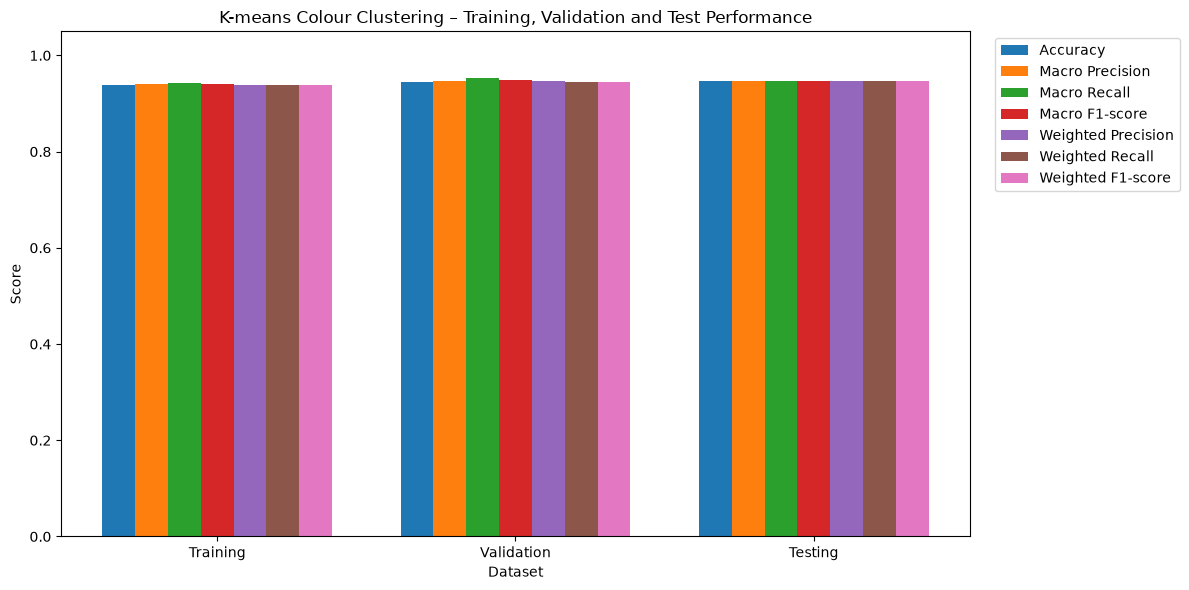

In [24]:
def metric_value(
    table: pd.DataFrame,
    metric_name: str
) -> float:

    return float(
        table.loc[
            table["Metric"] == metric_name,
            "Value"
        ].iloc[0]
    )


overall_metrics = pd.DataFrame(
    {
        "Dataset": [
            "Training",
            "Validation",
            "Testing"
        ],
        "Accuracy": [
            metric_value(
                training_metrics,
                "Accuracy"
            ),
            metric_value(
                validation_metrics,
                "Accuracy"
            ),
            metric_value(
                final_metrics,
                "Accuracy"
            )
        ],
        "Macro Precision": [
            metric_value(
                training_metrics,
                "Macro precision"
            ),
            metric_value(
                validation_metrics,
                "Macro precision"
            ),
            metric_value(
                final_metrics,
                "Macro precision"
            )
        ],
        "Macro Recall": [
            metric_value(
                training_metrics,
                "Macro recall"
            ),
            metric_value(
                validation_metrics,
                "Macro recall"
            ),
            metric_value(
                final_metrics,
                "Macro recall"
            )
        ],
        "Macro F1-score": [
            metric_value(
                training_metrics,
                "Macro F1-score"
            ),
            metric_value(
                validation_metrics,
                "Macro F1-score"
            ),
            metric_value(
                final_metrics,
                "Macro F1-score"
            )
        ],
        "Weighted Precision": [
            metric_value(
                training_metrics,
                "Weighted precision"
            ),
            metric_value(
                validation_metrics,
                "Weighted precision"
            ),
            metric_value(
                final_metrics,
                "Weighted precision"
            )
        ],
        "Weighted Recall": [
            metric_value(
                training_metrics,
                "Weighted recall"
            ),
            metric_value(
                validation_metrics,
                "Weighted recall"
            ),
            metric_value(
                final_metrics,
                "Weighted recall"
            )
        ],
        "Weighted F1-score": [
            metric_value(
                training_metrics,
                "Weighted F1-score"
            ),
            metric_value(
                validation_metrics,
                "Weighted F1-score"
            ),
            metric_value(
                final_metrics,
                "Weighted F1-score"
            )
        ]
    }
)

overall_metrics = overall_metrics.round(
    4
)

display(
    overall_metrics
)

overall_metrics.to_csv(
    RESULTS_DIR
    / "overall_train_validation_test_metrics.csv",
    index=False
)

metrics_for_plot = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1-score",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1-score"
]

x = np.arange(
    len(overall_metrics)
)

width = 0.11

fig, ax = plt.subplots(
    figsize=(12, 6)
)

offsets = (
    np.arange(len(metrics_for_plot))
    - (len(metrics_for_plot) - 1) / 2
) * width

for offset, metric in zip(
    offsets,
    metrics_for_plot
):

    ax.bar(
        x + offset,
        overall_metrics[metric],
        width,
        label=metric
    )

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        "Training",
        "Validation",
        "Testing"
    ]
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    "Dataset"
)

ax.set_title(
    "K-means Colour Clustering – "
    "Training, Validation and Test Performance"
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.tight_layout()

overall_metrics_figure = (
    FIGURES_DIR
    / "overall_train_validation_test_metrics.png"
)

fig.savefig(
    overall_metrics_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 12. Classification report and confusion matrix

The per-class classification results and confusion matrices are presented for the training, validation, and test subsets. Training and validation results are generated using the model fitted on the training subset only, while the final test results are generated using the fresh model fitted on the combined training and validation subsets.

Training per-class results


,Class,Precision,Recall,F1-score,Support
0,unripe,0.960478,0.971083,0.965752,1902
1,ripe,0.928768,0.958830,0.943560,3522
2,overripe,0.934142,0.917837,0.925918,2349
3,rotten,0.941926,0.919900,0.930783,4020


Validation per-class results


,Class,Precision,Recall,F1-score,Support
0,unripe,0.948571,0.994012,0.970760,167
1,ripe,0.928161,0.952802,0.940320,339
2,overripe,0.960177,0.947598,0.953846,229
3,rotten,0.951872,0.917526,0.934383,388


Test per-class results


...

,Predicted unripe,Predicted ripe,Predicted overripe,Predicted rotten
Actual unripe,1847,0,1,54
Actual ripe,1,3377,5,139
Actual overripe,0,158,2156,35
Actual rotten,75,101,146,3698


Validation confusion matrix


,Predicted unripe,Predicted ripe,Predicted overripe,Predicted rotten
Actual unripe,166,0,0,1
Actual ripe,0,323,0,16
Actual overripe,0,11,217,1
Actual rotten,9,14,9,356


Test confusion matrix


,Predicted unripe,Predicted ripe,Predicted overripe,Predicted rotten
Actual unripe,106,0,0,4
Actual ripe,0,149,0,5
Actual overripe,0,7,105,1
Actual rotten,4,1,8,172


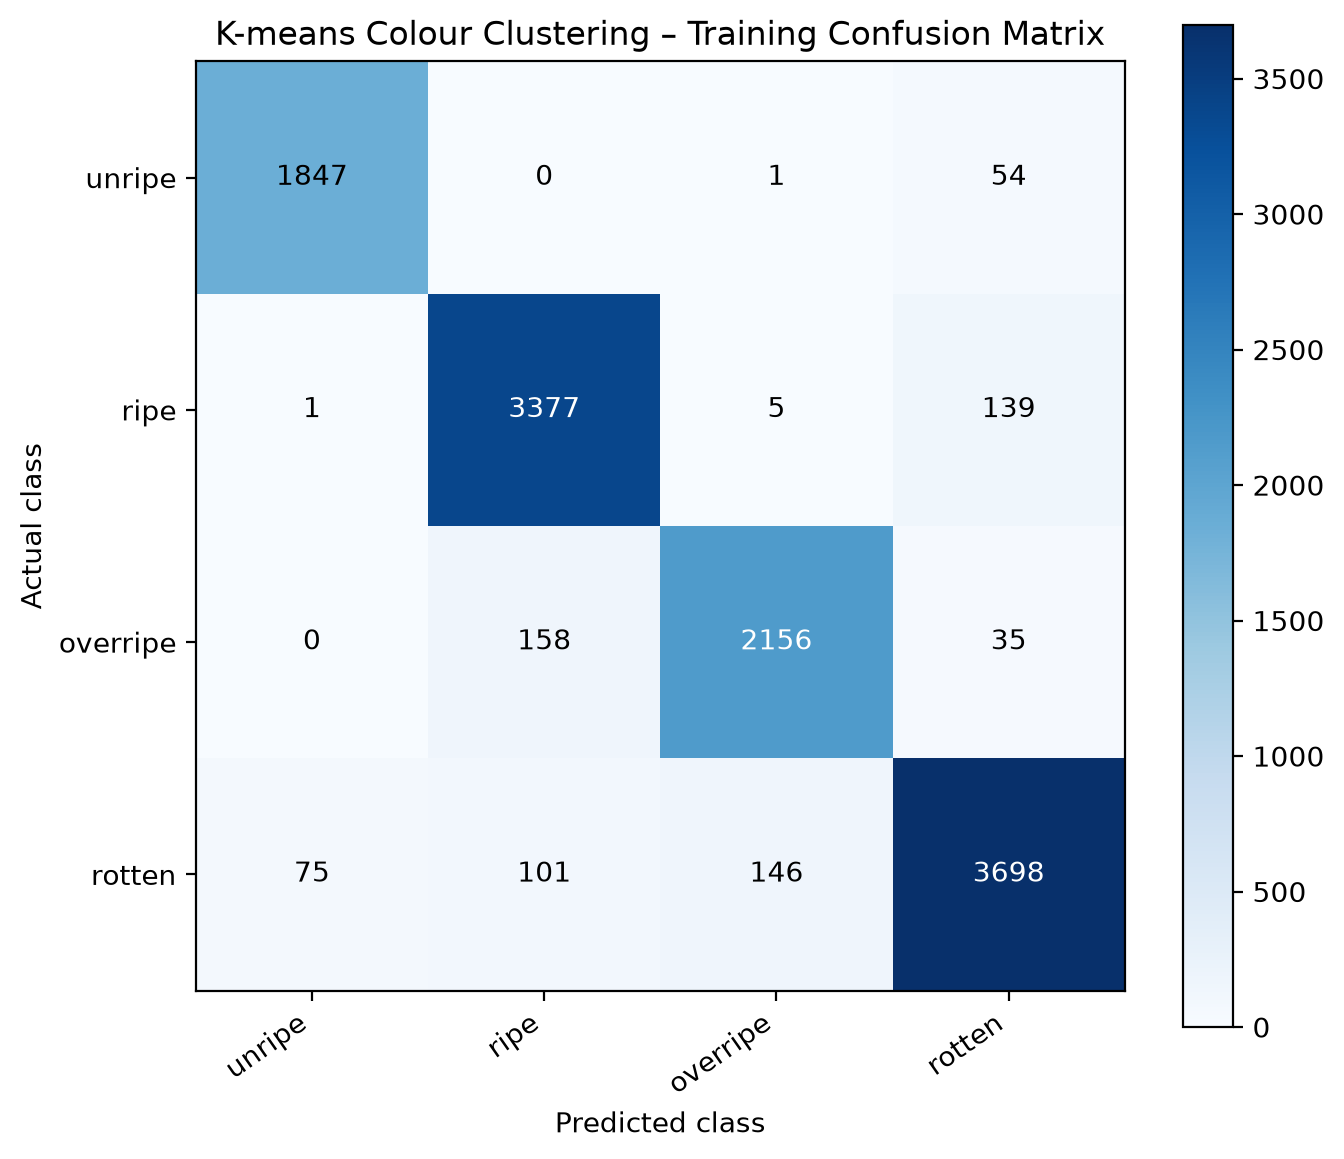

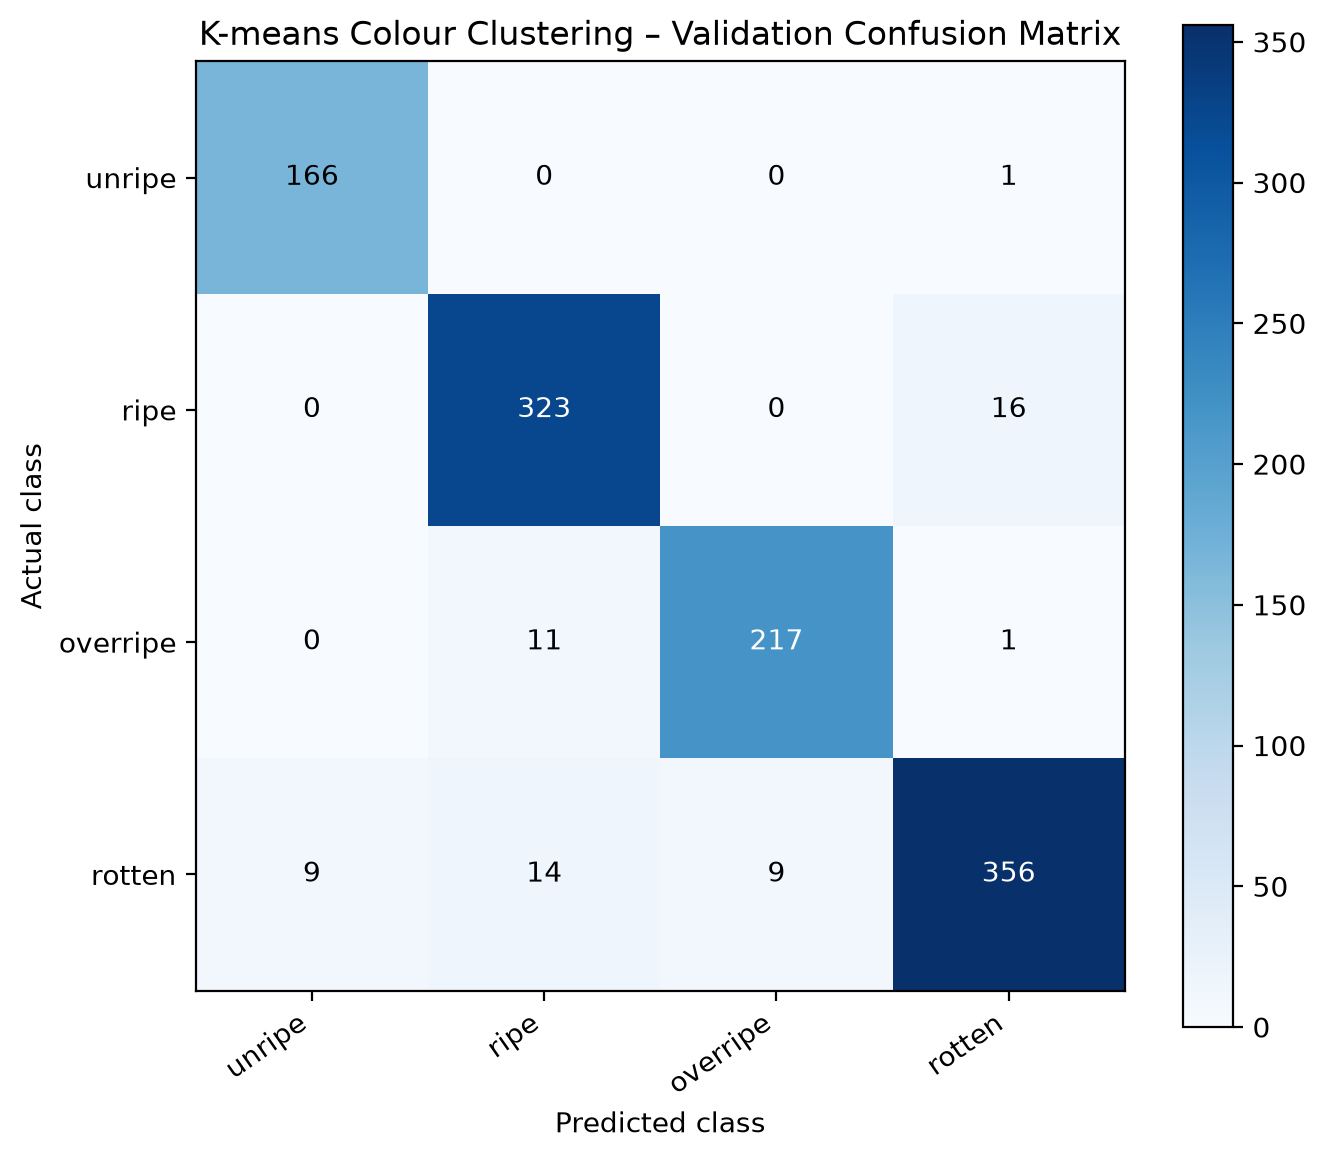

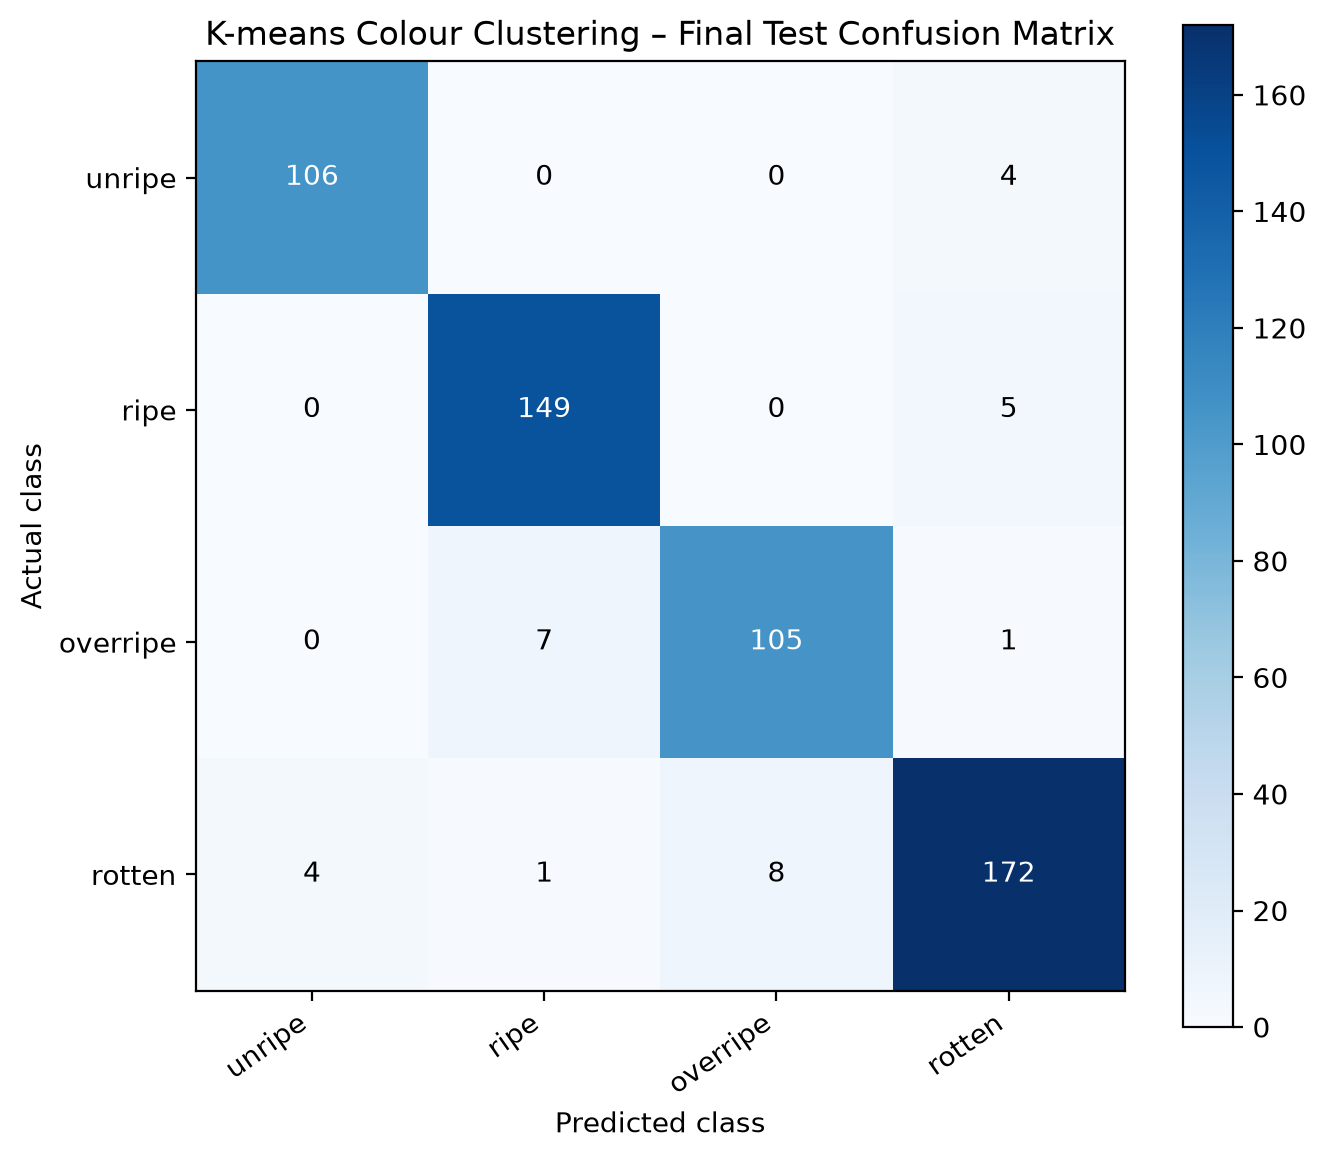

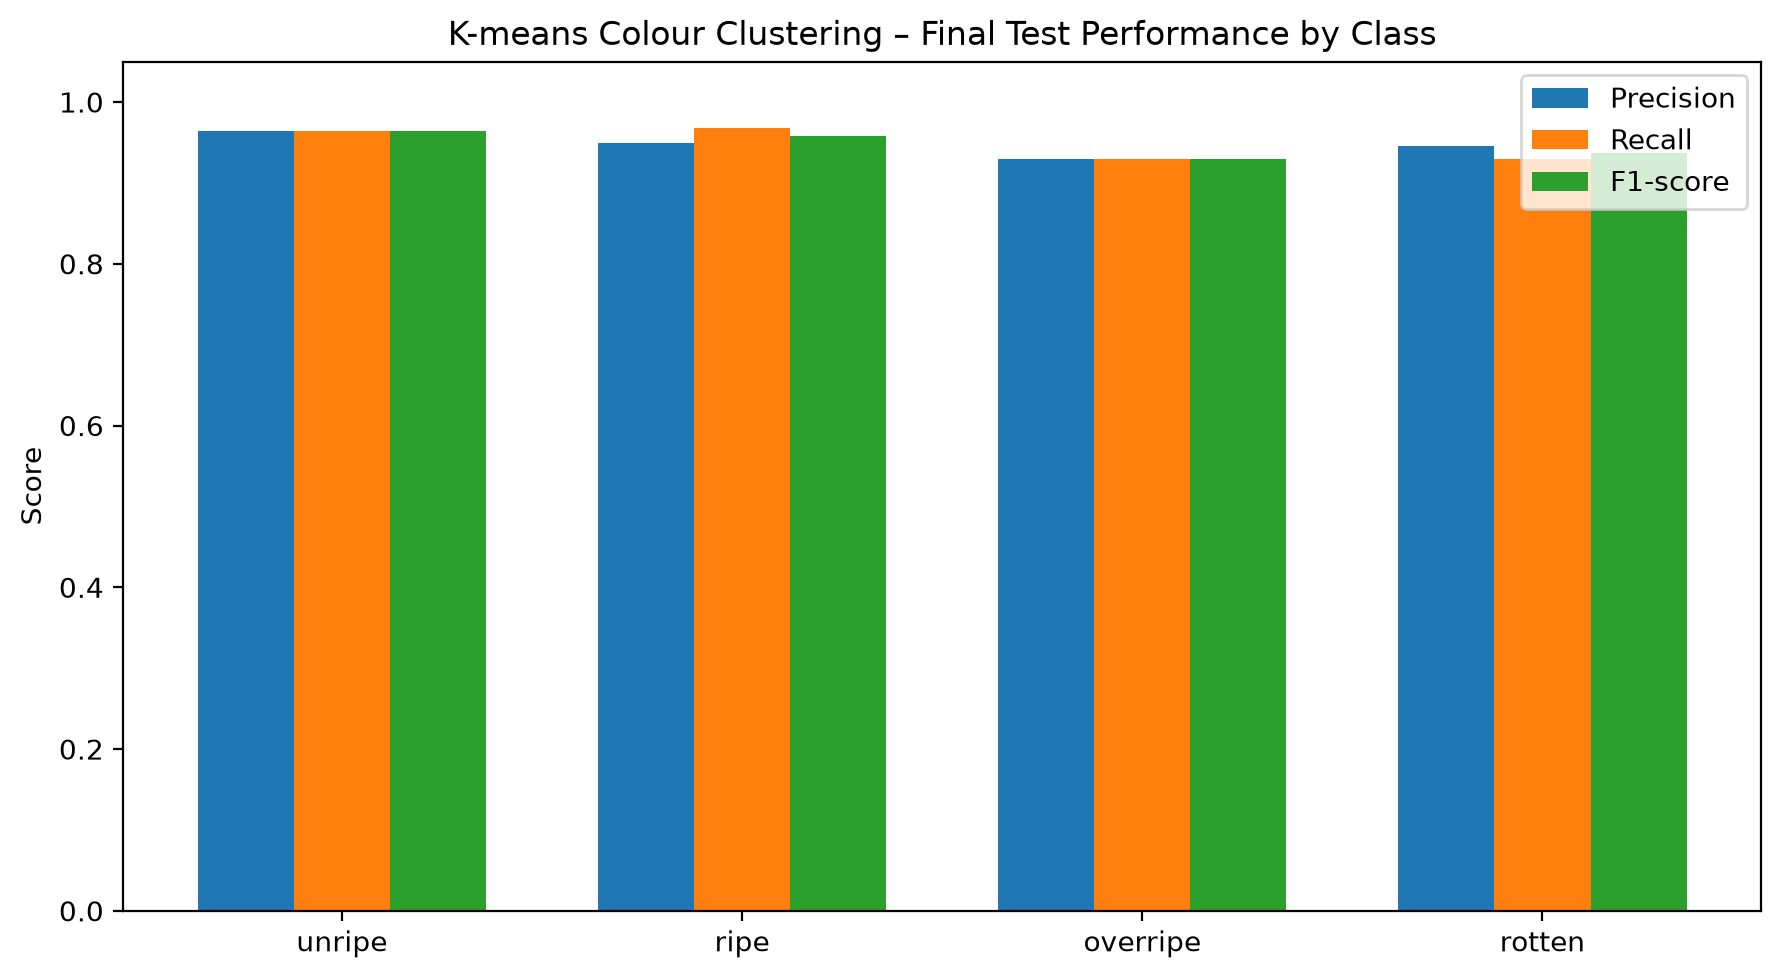

In [25]:
final_per_class.to_csv(
    RESULTS_DIR / "final_test_per_class_report.csv",
    index=False
)

print(
    "Training per-class results"
)

display(
    training_per_class
)


print(
    "Validation per-class results"
)

display(
    validation_per_class
)


print(
    "Test per-class results"
)

display(
    final_per_class
)


training_per_class.to_csv(
    RESULTS_DIR / "training_per_class_report.csv",
    index=False
)

validation_per_class.to_csv(
    RESULTS_DIR / "validation_per_class_report.csv",
    index=False
)

final_per_class.to_csv(
    RESULTS_DIR / "final_test_per_class_report.csv",
    index=False
)


training_confusion = confusion_matrix(
    train_frame["ground_truth_class"],
    training_prediction,
    labels=CLASS_ORDER
)

validation_confusion = confusion_matrix(
    valid_frame["ground_truth_class"],
    validation_prediction,
    labels=CLASS_ORDER
)

test_confusion = confusion_matrix(
    y_test,
    test_prediction,
    labels=CLASS_ORDER
)


training_confusion_table = pd.DataFrame(
    training_confusion,
    index=[
        f"Actual {name}"
        for name in CLASS_ORDER
    ],
    columns=[
        f"Predicted {name}"
        for name in CLASS_ORDER
    ]
)

validation_confusion_table = pd.DataFrame(
    validation_confusion,
    index=[
        f"Actual {name}"
        for name in CLASS_ORDER
    ],
    columns=[
        f"Predicted {name}"
        for name in CLASS_ORDER
    ]
)

test_confusion_table = pd.DataFrame(
    test_confusion,
    index=[
        f"Actual {name}"
        for name in CLASS_ORDER
    ],
    columns=[
        f"Predicted {name}"
        for name in CLASS_ORDER
    ]
)


print(
    "Training confusion matrix"
)

display(
    training_confusion_table
)


print(
    "Validation confusion matrix"
)

display(
    validation_confusion_table
)


print(
    "Test confusion matrix"
)

display(
    test_confusion_table
)


training_confusion_table.to_csv(
    RESULTS_DIR / "training_confusion_matrix.csv"
)

validation_confusion_table.to_csv(
    RESULTS_DIR / "validation_confusion_matrix.csv"
)

test_confusion_table.to_csv(
    RESULTS_DIR / "final_test_confusion_matrix.csv"
)


def save_confusion_figure(
    matrix: np.ndarray,
    output_path: Path,
    title: str
) -> Path:

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    image = ax.imshow(
        matrix,
        cmap="Blues"
    )

    fig.colorbar(
        image,
        ax=ax
    )

    ax.set(
        xticks=range(
            len(CLASS_ORDER)
        ),
        yticks=range(
            len(CLASS_ORDER)
        ),
        xticklabels=CLASS_ORDER,
        yticklabels=CLASS_ORDER,
        xlabel="Predicted class",
        ylabel="Actual class",
        title=title
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right"
    )

    threshold = (
        matrix.max() / 2
    )

    for row in range(
        matrix.shape[0]
    ):

        for column in range(
            matrix.shape[1]
        ):

            ax.text(
                column,
                row,
                int(
                    matrix[
                        row,
                        column
                    ]
                ),
                ha="center",
                va="center",
                color=(
                    "white"
                    if matrix[
                        row,
                        column
                    ] > threshold
                    else "black"
                )
            )

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close(
        fig
    )

    return output_path


def save_per_class_figure(
    table: pd.DataFrame,
    output_path: Path
) -> Path:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    positions = np.arange(
        len(CLASS_ORDER)
    )

    width = 0.24

    for offset, metric in zip(
        (-width, 0, width),
        (
            "Precision",
            "Recall",
            "F1-score"
        )
    ):

        ax.bar(
            positions + offset,
            table[metric],
            width,
            label=metric
        )

    ax.set_xticks(
        positions,
        CLASS_ORDER
    )

    ax.set_ylim(
        0,
        1.05
    )

    ax.set_ylabel(
        "Score"
    )

    ax.set_title(
        "K-means Colour Clustering – "
        "Final Test Performance by Class"
    )

    ax.legend()

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close(
        fig
    )

    return output_path


training_confusion_figure = (
    save_confusion_figure(
        training_confusion,
        FIGURES_DIR
        / "training_confusion_matrix.png",
        (
            "K-means Colour Clustering – "
            "Training Confusion Matrix"
        )
    )
)


validation_confusion_figure = (
    save_confusion_figure(
        validation_confusion,
        FIGURES_DIR
        / "validation_confusion_matrix.png",
        (
            "K-means Colour Clustering – "
            "Validation Confusion Matrix"
        )
    )
)


test_confusion_figure = (
    save_confusion_figure(
        test_confusion,
        FIGURES_DIR
        / "final_test_confusion_matrix.png",
        (
            "K-means Colour Clustering – "
            "Final Test Confusion Matrix"
        )
    )
)


per_class_figure = (
    save_per_class_figure(
        final_per_class,
        FIGURES_DIR
        / "final_test_per_class_performance.png"
    )
)


display(
    Image(
        filename=str(
            training_confusion_figure
        )
    )
)


display(
    Image(
        filename=str(
            validation_confusion_figure
        )
    )
)


display(
    Image(
        filename=str(
            test_confusion_figure
        )
    )
)


display(
    Image(
        filename=str(
            per_class_figure
        )
    )
)

### Combined training, validation, and test confusion matrices

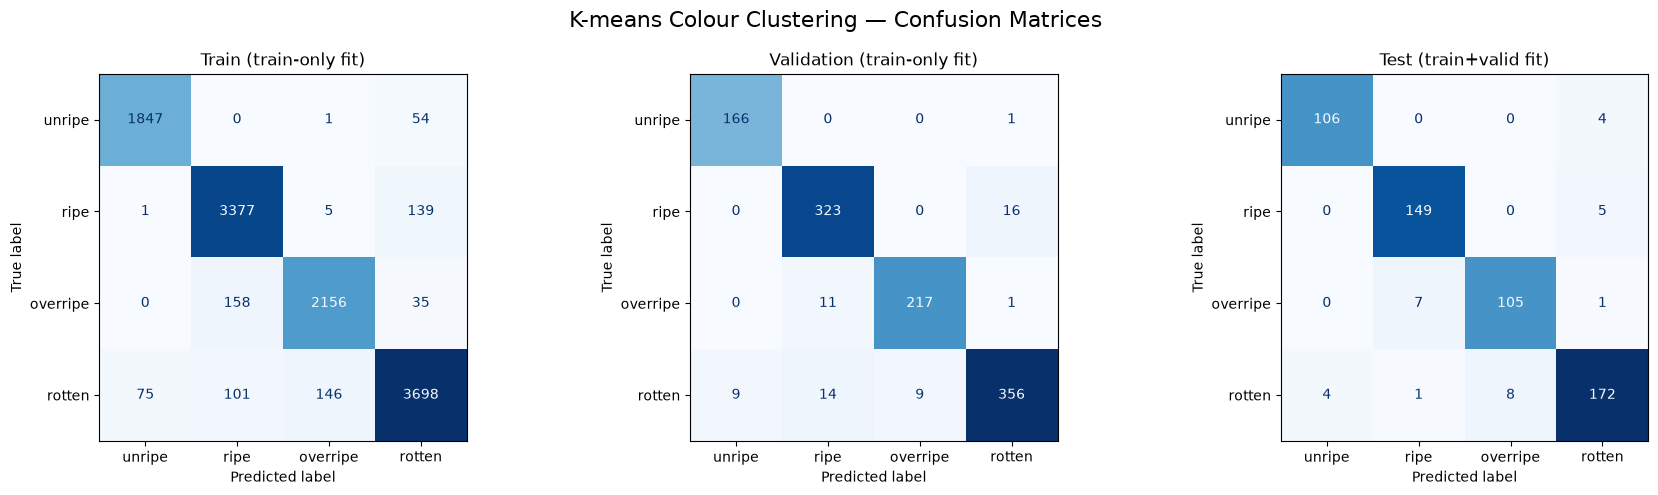

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

confusion_data = [
    ("Train (train-only fit)", training_confusion),
    ("Validation (train-only fit)", validation_confusion),
    ("Test (train+valid fit)", test_confusion)
]

for ax, (title, matrix) in zip(
    axes,
    confusion_data
):
    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=CLASS_ORDER
    )

    display.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False
    )

    ax.set_title(title)

fig.suptitle(
    "K-means Colour Clustering — Confusion Matrices",
    fontsize=16
)

plt.tight_layout()

combined_confusion_path = (
    RESULTS_DIR
    / "figures"
    / "combined_confusion_matrices.png"
)

combined_confusion_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    combined_confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Method summary

The final frozen K-means colour clustering configuration and evaluation policy are summarised below.

In [28]:
method_summary = pd.DataFrame({
    "Item": [
        "Input image size",
        "Noise reduction",
        "Colour representation",
        "Image-processing method",
        "Number of clusters",
        "Cluster ordering",
        "Feature vector",
        "Number of features",
        "Classifier",
        "Test policy"
    ],

    "Value": [
        "Standardised to 416 × 416 pixels",
        "3 × 3 median filtering",
        "CIELAB (L*, a*, b*)",
        "K-means colour clustering",
        f"K = {K_CLUSTERS}",
        "Ordered using b*, a*, and L*",
        "Cluster centroid L*, a*, b* and pixel proportion",
        len(CLUSTER_FEATURES),
        "StandardScaler() followed by default SVC()",
        "One final evaluation after train-plus-validation fitting"
    ]
})

display(method_summary)

method_summary.to_csv(
    RESULTS_DIR / "method_summary.csv",
    index=False
)

print(
    "Standalone run complete."
)

print(
    "Results saved to:",
    RESULTS_DIR
)

,Item,Value
0,Input image size,Standardised to 416 × 416 pixels
1,Noise reduction,3 × 3 median filtering
2,Colour representation,"CIELAB (L*, a*, b*)"
3,Image-processing method,K-means colour clustering
4,Number of clusters,K = 3
5,Cluster ordering,"Ordered using b*, a*, and L*"
6,Feature vector,"Cluster centroid L*, a*, b* and pixel proportion"
7,Number of features,12
8,Classifier,StandardScaler() followed by default SVC()
9,Test policy,One final evaluation after train-plus-validati...


Standalone run complete.
Results saved to: C:\Users\Lim Kai wei\Downloads\results\20260906_005900_+0800
